In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
def plot_each_metric(log_file, save_dir=None):
    # Read CSV file
    df = pd.read_csv(log_file)

    # Extract epoch
    epochs = df["epoch"]

    # If save directory is not specified, use the same directory as the log file
    if save_dir is None:
        save_dir = os.path.dirname(log_file)
    os.makedirs(save_dir, exist_ok=True)

    # Plot each column (except epoch) separately
    for col in df.columns:
        if col == "epoch":
            continue

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, df[col], linewidth=2)
        plt.yscale("log")
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel(col.replace("_", " ").title(), fontsize=12)
        plt.title(f"{col.replace('_', ' ').title()} vs Epoch", fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()

        # Save the figure
        save_path = os.path.join(save_dir, f"{col}.pdf")
        plt.savefig(save_path, dpi=800)
        plt.tight_layout()
        plt.show()
        # print(f"✅ Saved: {save_path}")
        plt.close()

    # print("📈 All metric curves have been plotted and saved.")

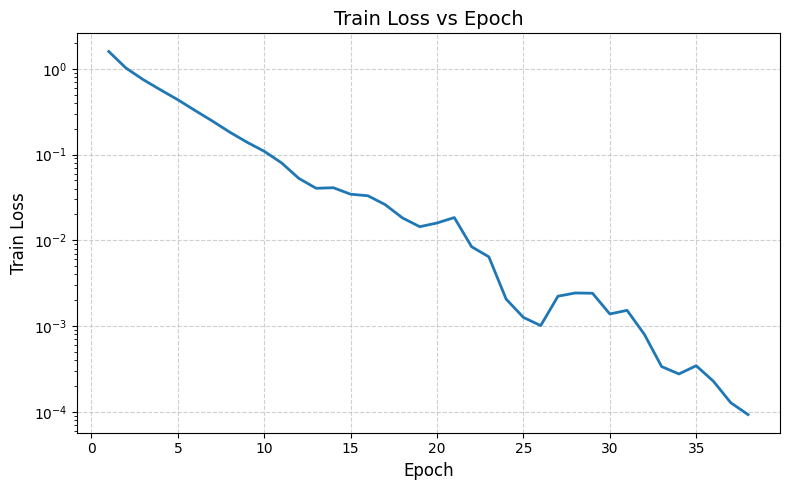

In [3]:
log_file = "./logs/lr_0.2_bs_64_seed_0/training_log.csv"  # Path to your log file
plot_each_metric(log_file, save_dir='./cv_log/lr_0.2_bs_64_seed_0')

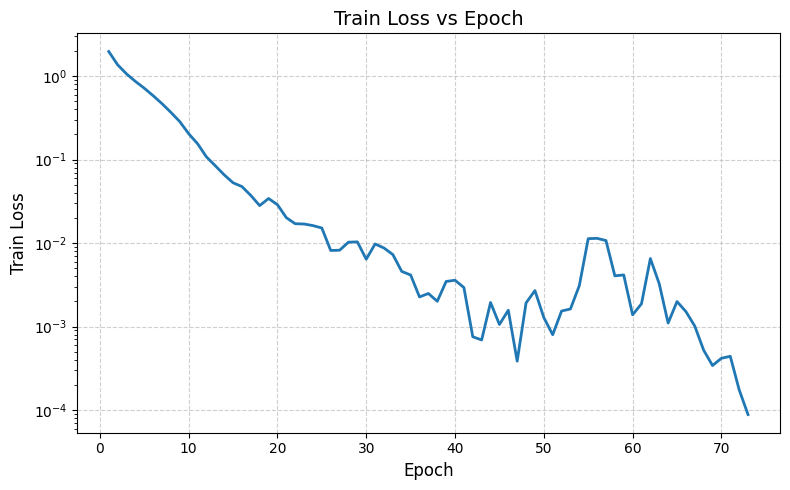

In [4]:
log_file = "./logs/lr_0.8_bs_64_seed_0/training_log.csv"  # Path to your log file
plot_each_metric(log_file, save_dir='./cv_log/lr_0.8_bs_64_seed_0')

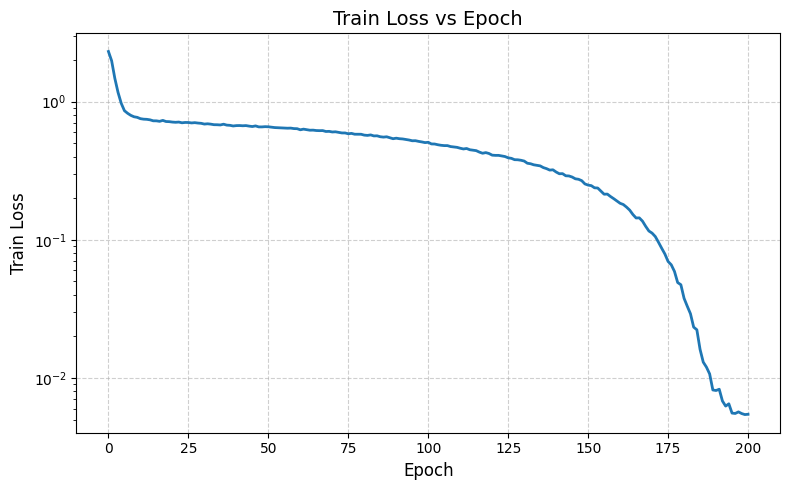

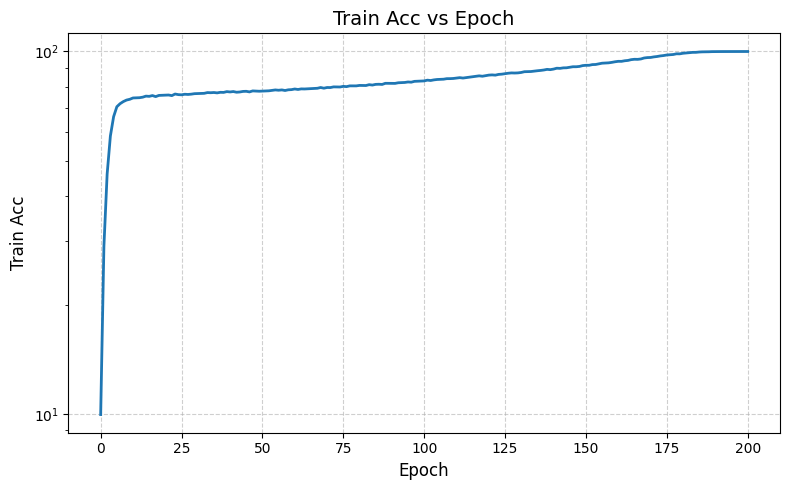

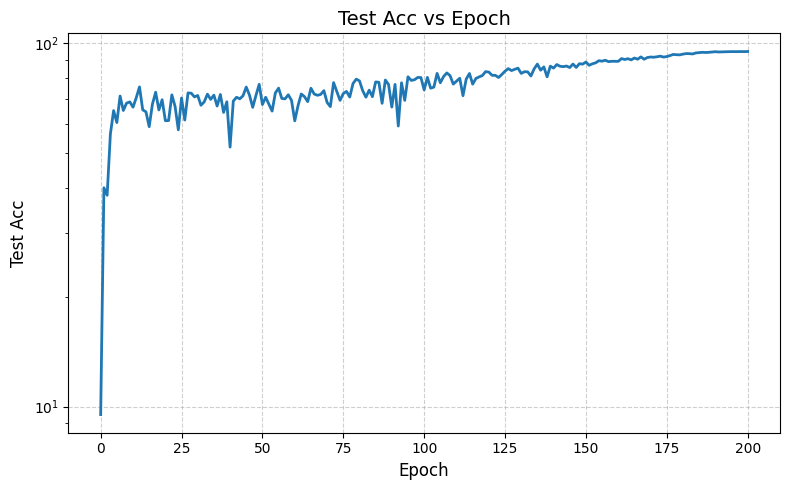

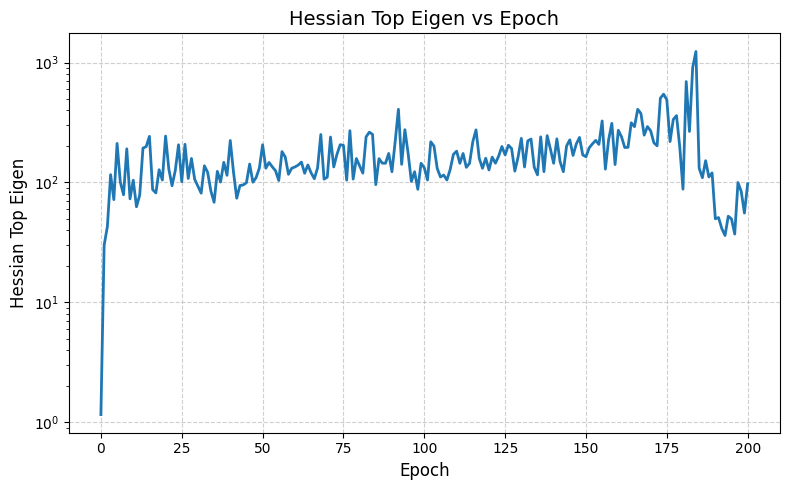

In [5]:
log_file = "./results/CIFAR-10/training_log.csv"  # Path to your log file
plot_each_metric(log_file, save_dir='./cv_log/CIFAR-10')